<a href="https://colab.research.google.com/github/biswal-prem-5677/Coding-Journey/blob/main/ai/03_deep_learning/architectures/cnn/experiment_cnn_mnist_progressive_improvement_comparision_pytorch_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
# ============================================
# LEVEL 1: BASIC CNN
# ============================================

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

# -------------------------------
# 1. Load Dataset
# -------------------------------
transform = transforms.ToTensor()

train_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

# -------------------------------
# 2. Model
# -------------------------------
class BasicCNN(nn.Module):
    def __init__(self):
        super().__init__()

        # First feature extractor
        self.conv1 = nn.Conv2d(1, 16, 3)

        # Second feature extractor
        self.conv2 = nn.Conv2d(16, 32, 3)

        # Final classifier
        self.fc = nn.Linear(32 * 24 * 24, 10)

    def forward(self, x):
        # Detect edges
        x = torch.relu(self.conv1(x))

        # Detect patterns
        x = torch.relu(self.conv2(x))

        # Flatten (image → vector)
        x = x.view(x.size(0), -1)

        # Classify digit
        return self.fc(x)


model = BasicCNN()

# -------------------------------
# 3. Training Setup
# -------------------------------
optimizer = optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.CrossEntropyLoss()

# 🔥 IMPORTANT: Track loss
loss_history_cnn = []

# -------------------------------
# 4. Training Loop
# -------------------------------
for epoch in range(3):
    total_loss = 0

    for images, labels in train_loader:
        optimizer.zero_grad()

        outputs = model(images)

        loss = loss_fn(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)

    # ✅ Store loss
    loss_history_cnn.append(avg_loss)

    print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")

# -------------------------------
# 5. Evaluation (Accuracy)
# -------------------------------
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in train_loader:  # using train set for Level 1
        outputs = model(images)

        _, preds = torch.max(outputs, 1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

accuracy_cnn = correct / total

print("Level 1 Accuracy:", accuracy_cnn)

Epoch 1, Loss: 0.1663
Epoch 2, Loss: 0.0548
Epoch 3, Loss: 0.0378
Level 1 Accuracy: 0.9926166666666667


In [9]:
# ============================================
# LEVEL 2: CNN WITH POOLING
# ============================================

import torch
import torch.nn as nn
import torch.optim as optim

# -------------------------------
# 1. Model (Improved CNN)
# -------------------------------
class BetterCNN(nn.Module):
    def __init__(self):
        super().__init__()

        # First conv block
        self.conv1 = nn.Conv2d(1, 16, 3)
        self.pool = nn.MaxPool2d(2)

        # Second conv block
        self.conv2 = nn.Conv2d(16, 32, 3)

        # Fully connected layer
        self.fc = nn.Linear(32 * 5 * 5, 10)

    def forward(self, x):

        # Feature extraction
        x = torch.relu(self.conv1(x))
        x = self.pool(x)  # keep important info

        x = torch.relu(self.conv2(x))
        x = self.pool(x)

        # Flatten
        x = x.view(x.size(0), -1)

        # Classification
        return self.fc(x)


model2 = BetterCNN()

# -------------------------------
# 2. Training Setup
# -------------------------------
optimizer2 = optim.Adam(model2.parameters(), lr=0.001)
loss_fn2 = nn.CrossEntropyLoss()

# 🔥 Track loss
loss_history_cnn2 = []

# -------------------------------
# 3. Training Loop
# -------------------------------
for epoch in range(3):
    total_loss = 0

    for images, labels in train_loader:  # reuse same data
        optimizer2.zero_grad()

        outputs = model2(images)

        loss = loss_fn2(outputs, labels)

        loss.backward()
        optimizer2.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)

    # ✅ Store loss
    loss_history_cnn2.append(avg_loss)

    print(f"[Level 2] Epoch {epoch+1}, Loss: {avg_loss:.4f}")

# -------------------------------
# 4. Evaluation (Accuracy)
# -------------------------------
model2.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in train_loader:
        outputs = model2(images)

        _, preds = torch.max(outputs, 1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

accuracy_cnn2 = correct / total

print("Level 2 Accuracy:", accuracy_cnn2)

[Level 2] Epoch 1, Loss: 0.2615
[Level 2] Epoch 2, Loss: 0.0747
[Level 2] Epoch 3, Loss: 0.0573
Level 2 Accuracy: 0.9859


In [10]:
# ============================================
# LEVEL 3: CNN WITH REAL EVALUATION
# ============================================

import torch
import torchvision
import torchvision.transforms as transforms
from sklearn.metrics import confusion_matrix
import numpy as np

# -------------------------------
# 1. Load Test Dataset
# -------------------------------
transform = transforms.ToTensor()

test_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

# -------------------------------
# 2. Use TRAINED MODEL (IMPORTANT)
# -------------------------------
# ❌ DON'T do: model = BetterCNN()
# ✅ Use already trained model:

model3 = model2   # reuse trained Level 2 model

# -------------------------------
# 3. Evaluation
# -------------------------------
model3.eval()

correct = 0
total = 0

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:

        outputs = model3(images)

        _, preds = torch.max(outputs, 1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

        # Store for confusion matrix
        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())

accuracy_cnn3 = correct / total

print("Level 3 Test Accuracy:", accuracy_cnn3)

# -------------------------------
# 4. Confusion Matrix Data
# -------------------------------
cm = confusion_matrix(all_labels, all_preds)

print("Confusion Matrix Ready ✅")

Level 3 Test Accuracy: 0.986
Confusion Matrix Ready ✅


Confusion Matrix:

[[ 966    0    0    0    0    5    4    2    3    0]
 [   0 1130    1    1    0    0    1    2    0    0]
 [   1    2 1010    1    1    1    0    9    7    0]
 [   0    0    1 1002    0    3    0    3    1    0]
 [   1    0    0    0  964    0    5    2    2    8]
 [   1    0    1    5    0  881    2    1    1    0]
 [   0    2    0    1    1    3  951    0    0    0]
 [   0    2    3    4    0    0    0 1018    0    1]
 [   2    0    2    2    1    2    2    4  956    3]
 [   2    4    0    4    1    6    0    6    4  982]]


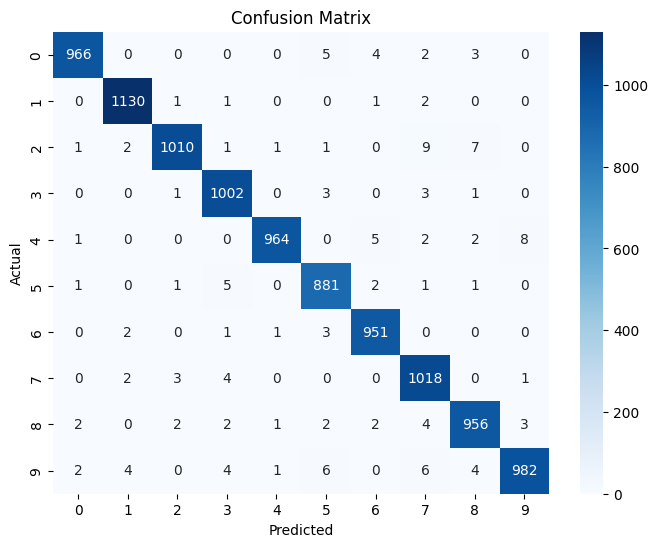

In [11]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_preds)

print("Confusion Matrix:\n")
print(cm)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

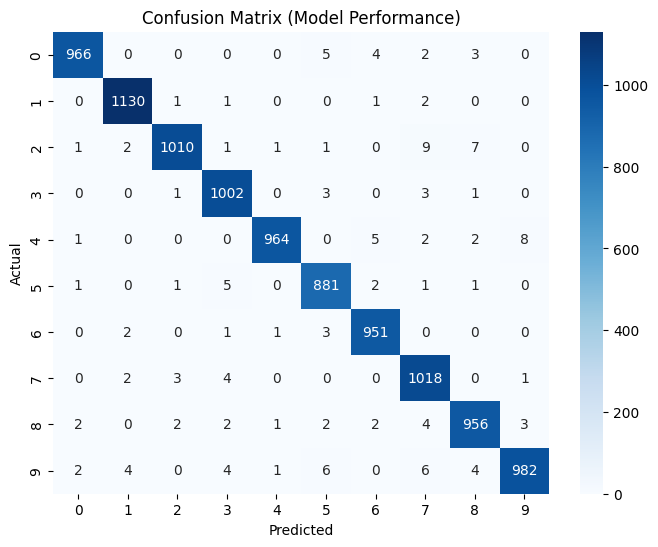

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix (Model Performance)")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [13]:
# ============================================
# LEVEL 4: PRODUCTION CNN (GPU + FULL PIPELINE)
# ============================================

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

# -------------------------------
# 1. Device
# -------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# -------------------------------
# 2. Model
# -------------------------------
class ProductionCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(1, 16, 3)
        self.pool = nn.MaxPool2d(2)

        self.conv2 = nn.Conv2d(16, 32, 3)

        self.fc = nn.Linear(32 * 5 * 5, 10)

    def forward(self, x):
        x = torch.relu(self.conv1(x))
        x = self.pool(x)

        x = torch.relu(self.conv2(x))
        x = self.pool(x)

        x = x.view(x.size(0), -1)
        return self.fc(x)


model4 = ProductionCNN().to(device)

# -------------------------------
# 3. Training Setup
# -------------------------------
optimizer4 = optim.Adam(model4.parameters(), lr=0.001)
loss_fn4 = nn.CrossEntropyLoss()

loss_history_cnn4 = []

# -------------------------------
# 4. Training Loop (GPU)
# -------------------------------
for epoch in range(3):
    total_loss = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer4.zero_grad()

        outputs = model4(images)
        loss = loss_fn4(outputs, labels)

        loss.backward()
        optimizer4.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    loss_history_cnn4.append(avg_loss)

    print(f"[Level 4] Epoch {epoch+1}, Loss: {avg_loss:.4f}")

# -------------------------------
# 5. Evaluation (TEST SET)
# -------------------------------
model4.eval()

correct = 0
total = 0

confidences = []

with torch.no_grad():
    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model4(images)

        probs = torch.softmax(outputs, dim=1)

        max_conf, preds = torch.max(probs, 1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

        confidences.extend(max_conf.cpu().numpy())

accuracy_cnn4 = correct / total

print("Level 4 Accuracy:", accuracy_cnn4)

Using device: cpu
[Level 4] Epoch 1, Loss: 0.2724
[Level 4] Epoch 2, Loss: 0.0775
[Level 4] Epoch 3, Loss: 0.0581
Level 4 Accuracy: 0.9832


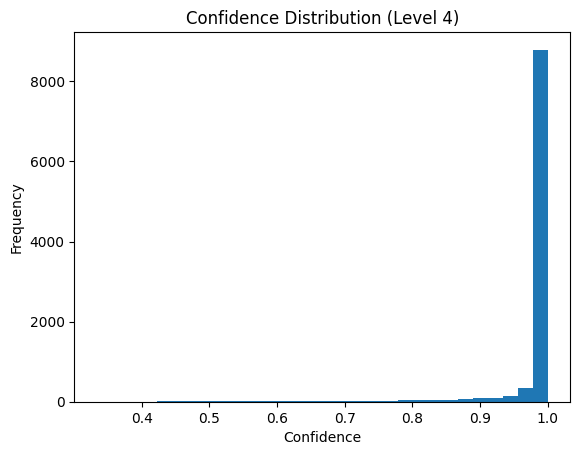

In [14]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(confidences, bins=30)
plt.title("Confidence Distribution (Level 4)")
plt.xlabel("Confidence")
plt.ylabel("Frequency")
plt.show()

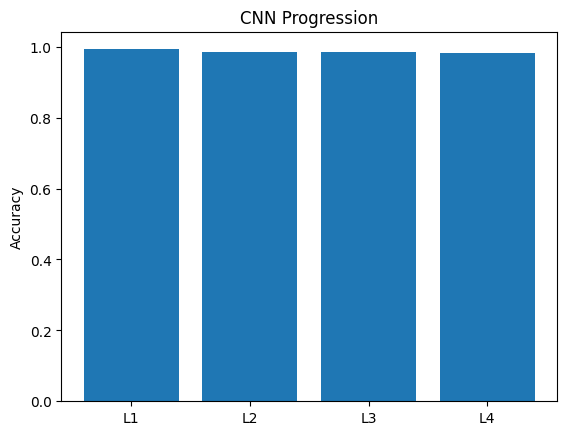

In [15]:
levels = ["L1", "L2", "L3", "L4"]
accuracies = [accuracy_cnn, accuracy_cnn2, accuracy_cnn3, accuracy_cnn4]

import matplotlib.pyplot as plt

plt.figure()
plt.bar(levels, accuracies)
plt.title("CNN Progression")
plt.ylabel("Accuracy")
plt.show()

In [16]:
print("\n===== FINAL ACCURACY COMPARISON =====")

print(f"Level 1 Accuracy: {accuracy_cnn:.4f}")
print(f"Level 2 Accuracy: {accuracy_cnn2:.4f}")
print(f"Level 3 Accuracy: {accuracy_cnn3:.4f}")
print(f"Level 4 Accuracy: {accuracy_cnn4:.4f}")


===== FINAL ACCURACY COMPARISON =====
Level 1 Accuracy: 0.9926
Level 2 Accuracy: 0.9859
Level 3 Accuracy: 0.9860
Level 4 Accuracy: 0.9832


In [17]:
levels = ["Level 1", "Level 2", "Level 3", "Level 4"]
accuracies = [accuracy_cnn, accuracy_cnn2, accuracy_cnn3, accuracy_cnn4]

print("\n===== ACCURACY TABLE =====")

for lvl, acc in zip(levels, accuracies):
    print(f"{lvl:<10} : {acc:.4f}")


===== ACCURACY TABLE =====
Level 1    : 0.9926
Level 2    : 0.9859
Level 3    : 0.9860
Level 4    : 0.9832


In [18]:
best_idx = accuracies.index(max(accuracies))

print("\nBest Model:", levels[best_idx])


Best Model: Level 1


In [19]:
from sklearn.metrics import confusion_matrix

def get_confusion_matrix(model, loader, device="cpu"):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    return confusion_matrix(all_labels, all_preds)

In [20]:
cm1 = get_confusion_matrix(model, test_loader)      # Level 1
cm2 = get_confusion_matrix(model2, test_loader)     # Level 2
cm3 = get_confusion_matrix(model3, test_loader)     # Level 3
cm4 = get_confusion_matrix(model4, test_loader, device=device)  # Level 4

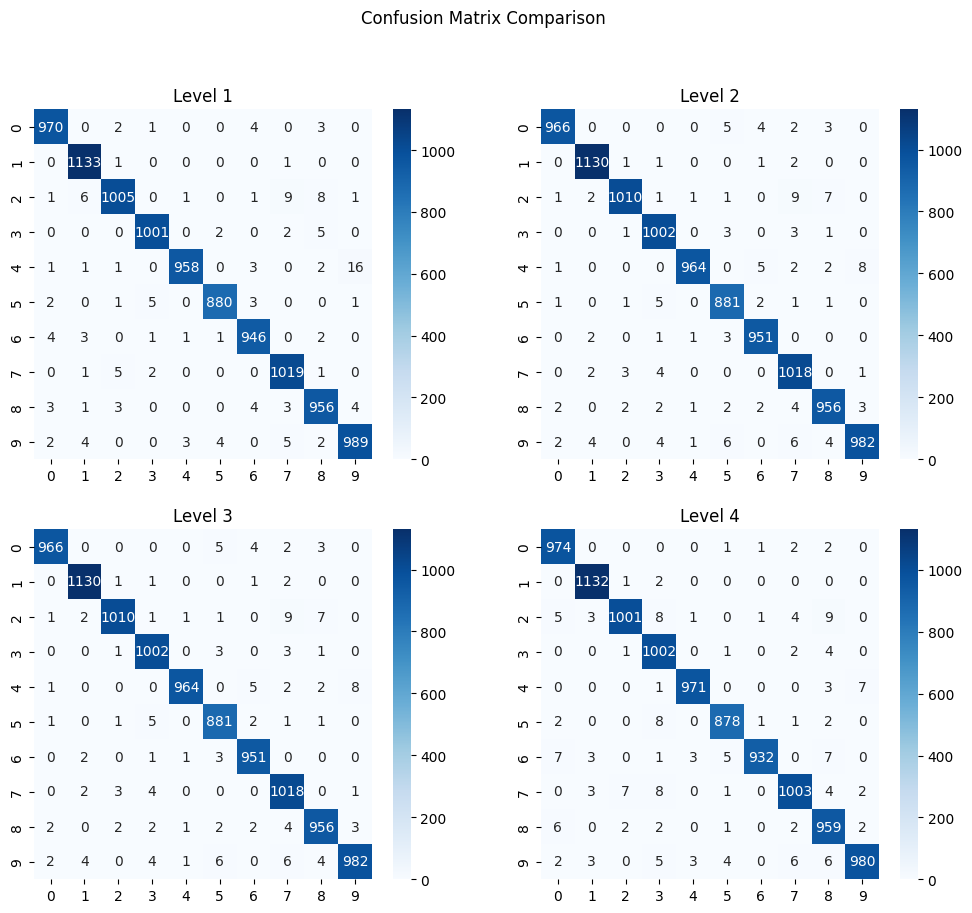

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

cms = [cm1, cm2, cm3, cm4]
titles = ["Level 1", "Level 2", "Level 3", "Level 4"]

plt.figure(figsize=(12,10))

for i, cm in enumerate(cms):
    plt.subplot(2,2,i+1)
    sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
    plt.title(titles[i])

plt.suptitle("Confusion Matrix Comparison")
plt.show()

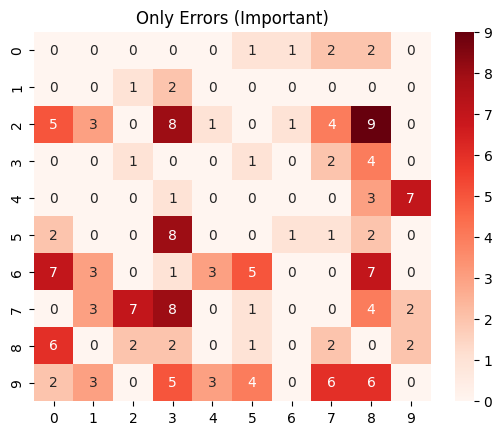

In [30]:
cm_no_diag = cm.copy()

for i in range(len(cm)):
    cm_no_diag[i, i] = 0  # remove correct predictions

sns.heatmap(cm_no_diag, annot=True, cmap="Reds")
plt.title("Only Errors (Important)")
plt.show()

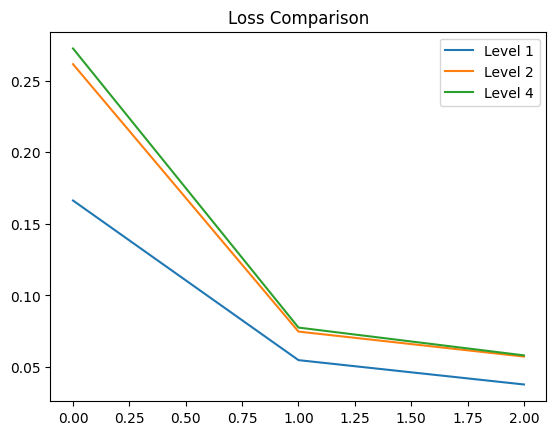

In [23]:
plt.figure()

plt.plot(loss_history_cnn, label="Level 1")
plt.plot(loss_history_cnn2, label="Level 2")
plt.plot(loss_history_cnn4, label="Level 4")

plt.title("Loss Comparison")
plt.legend()
plt.show()

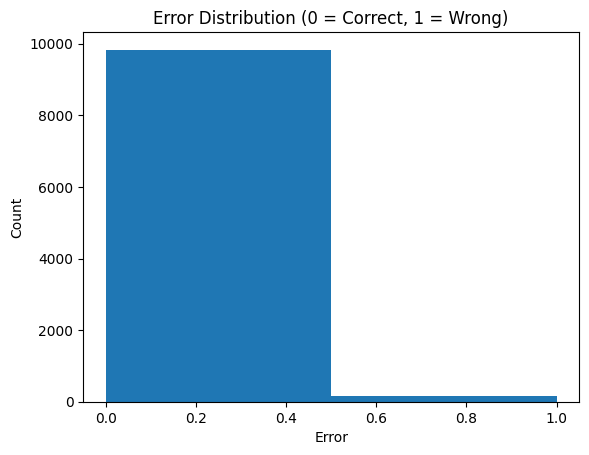

In [27]:
errors = []

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model4(images.to(device))
        _, preds = torch.max(outputs, 1)

        # ✅ FIXED
        errors.extend((preds.cpu() != labels).int().numpy())

import matplotlib.pyplot as plt

plt.figure()
plt.hist(errors, bins=2)
plt.title("Error Distribution (0 = Correct, 1 = Wrong)")
plt.xlabel("Error")
plt.ylabel("Count")
plt.show()

In [28]:
import numpy as np

correct_count = np.sum(np.array(errors) == 0)
wrong_count = np.sum(np.array(errors) == 1)

print(f"Correct: {correct_count}")
print(f"Wrong: {wrong_count}")

Correct: 9832
Wrong: 168


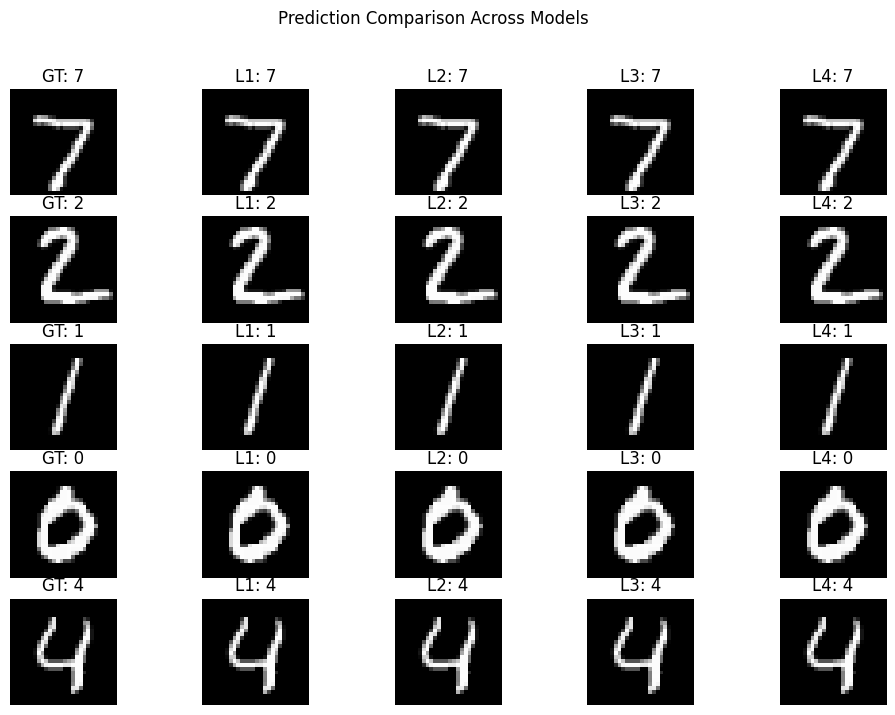

In [31]:
import matplotlib.pyplot as plt

# Get one batch
images, labels = next(iter(test_loader))

models = [model, model2, model3, model4]
titles = ["L1", "L2", "L3", "L4"]

plt.figure(figsize=(12,8))

for i in range(5):  # show 5 images
    img = images[i]

    plt.subplot(5,5,i*5+1)
    plt.imshow(img[0], cmap='gray')
    plt.title(f"GT: {labels[i].item()}")
    plt.axis('off')

    for j, m in enumerate(models):
        m.eval()
        with torch.no_grad():
            out = m(img.unsqueeze(0).to(device if j==3 else "cpu"))
            pred = torch.argmax(out).item()

        plt.subplot(5,5,i*5 + (j+2))
        plt.imshow(img[0], cmap='gray')
        plt.title(f"{titles[j]}: {pred}")
        plt.axis('off')

plt.suptitle("Prediction Comparison Across Models")
plt.show()

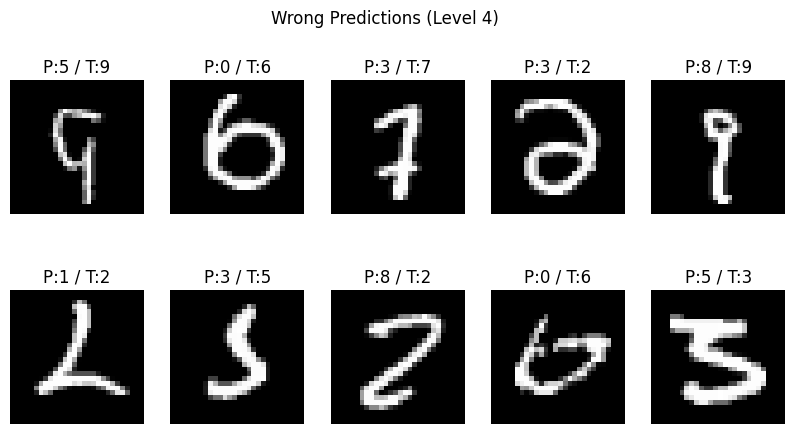

In [32]:
wrong_images = []
wrong_preds = []
wrong_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model4(images.to(device))
        _, preds = torch.max(outputs, 1)

        for i in range(len(labels)):
            if preds[i].cpu() != labels[i]:
                wrong_images.append(images[i])
                wrong_preds.append(preds[i].cpu().item())
                wrong_labels.append(labels[i].item())

        if len(wrong_images) > 10:
            break

plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(wrong_images[i][0], cmap='gray')
    plt.title(f"P:{wrong_preds[i]} / T:{wrong_labels[i]}")
    plt.axis('off')

plt.suptitle("Wrong Predictions (Level 4)")
plt.show()

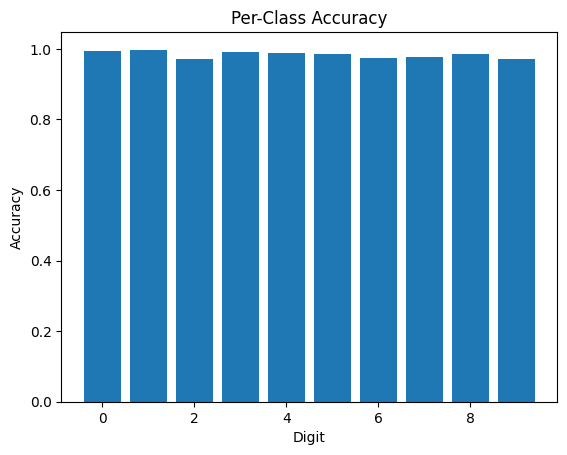

In [33]:
import numpy as np

cm = cm4  # use best model

class_acc = cm.diagonal() / cm.sum(axis=1)

plt.figure()
plt.bar(range(10), class_acc)

plt.title("Per-Class Accuracy")
plt.xlabel("Digit")
plt.ylabel("Accuracy")

plt.show()

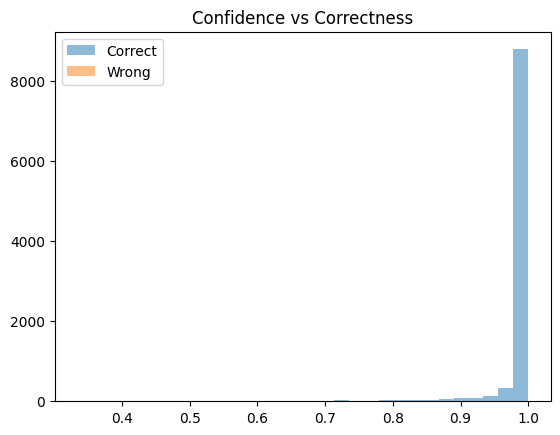

In [35]:
correct_conf = []
wrong_conf = []

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model4(images.to(device))
        probs = torch.softmax(outputs, dim=1)

        conf, preds = torch.max(probs, 1)

        for i in range(len(labels)):
            if preds[i].cpu() == labels[i]:
                correct_conf.append(conf[i].cpu().item())
            else:
                wrong_conf.append(conf[i].cpu().item())

plt.figure()

plt.hist(correct_conf, bins=30, alpha=0.5, label="Correct")
plt.hist(wrong_conf, bins=30, alpha=0.5, label="Wrong")

plt.legend()
plt.title("Confidence vs Correctness")
plt.show()